In [1]:
# ============================================
# DISTILBERT SENTIMENT ANALYSIS
# ============================================

# Data handling
import pandas as pd
import numpy as np

# Deep Learning
import torch

# Hugging Face Dataset
from datasets import Dataset

# Train Test Split
from sklearn.model_selection import train_test_split

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# DistilBERT
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

# Plotting
import matplotlib.pyplot as plt

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/preprocessed_reviews.csv")

df.head()

,Text,Sentiment,Clean_Text,BERT_Text,Label
0,I have bought several of the Vitality canned d...,Positive,bought several vitality canned dog food produc...,I have bought several of the Vitality canned d...,2
1,Product arrived labeled as Jumbo Salted Peanut...,Negative,product arrived labeled jumbo salted peanutsth...,Product arrived labeled as Jumbo Salted Peanut...,0
2,This is a confection that has been around a fe...,Positive,confection around century light pillowy citrus...,This is a confection that has been around a fe...,2
3,If you are looking for the secret ingredient i...,Negative,looking secret ingredient robitussin believe f...,If you are looking for the secret ingredient i...,0
4,Great taffy at a great price. There was a wid...,Positive,great taffy great price wide assortment yummy ...,Great taffy at a great price. There was a wide...,2


In [3]:
df = df[["BERT_Text", "Label"]]

df.head()

,BERT_Text,Label
0,I have bought several of the Vitality canned d...,2
1,Product arrived labeled as Jumbo Salted Peanut...,0
2,This is a confection that has been around a fe...,2
3,If you are looking for the secret ingredient i...,0
4,Great taffy at a great price. There was a wide...,2


In [4]:
df = df.dropna()

df.reset_index(drop=True, inplace=True)

print(df.shape)

(568454, 2)


In [5]:
df["Label"].value_counts()

Label
2    443777
0     82037
1     42640
Name: count, dtype: int64

In [6]:
# Create a stratified sample of 50,000 reviews

sample_df, _ = train_test_split(
    df,
    train_size=50000,
    stratify=df["Label"],
    random_state=42
)

sample_df.reset_index(drop=True, inplace=True)

print("Sample Shape:", sample_df.shape)
print("\nClass Distribution:")
print(sample_df["Label"].value_counts())

Sample Shape: (50000, 2)

Class Distribution:
Label
2    39034
0     7216
1     3750
Name: count, dtype: int64


In [7]:
train_df, test_df = train_test_split(
    sample_df,
    test_size=0.20,
    stratify=sample_df["Label"],
    random_state=42
)

print("Training Data:", train_df.shape)
print("Testing Data :", test_df.shape)

Training Data: (40000, 2)
Testing Data : (10000, 2)


In [8]:
train_dataset = Dataset.from_pandas(train_df)

test_dataset = Dataset.from_pandas(test_df)

In [9]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    "distilbert-base-uncased"
)

In [10]:
def tokenize(batch):

    return tokenizer(
        batch["BERT_Text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [11]:
train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

In [12]:
test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [13]:
train_dataset = train_dataset.rename_column(
    "Label",
    "labels"
)

test_dataset = test_dataset.rename_column(
    "Label",
    "labels"
)

In [14]:
train_dataset = train_dataset.remove_columns(
    ["BERT_Text"]
)

test_dataset = test_dataset.remove_columns(
    ["BERT_Text"]
)

In [15]:
train_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

test_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels"
    ]
)

In [16]:
print(train_dataset)

print(test_dataset)

Dataset({
    features: ['labels', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 40000
})
Dataset({
    features: ['labels', '__index_level_0__', 'input_ids', 'attention_mask'],
    num_rows: 10000
})


In [17]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [18]:
def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = np.argmax(
        predictions,
        axis=1
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro"
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1

    }

In [19]:
training_args = TrainingArguments(

    output_dir="../distilbert_output",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    logging_steps=100,

    save_total_limit=2,

    report_to="none"
)

In [ ]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    processing_class=tokenizer,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
    
)5

In [21]:
trainer.train(resume_from_checkpoint=True)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
3,0.176399,0.358204,0.897300,0.746401,0.710801,0.727141


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=7500, training_loss=0.056739163716634115, metrics={'train_runtime': 17009.079, 'train_samples_per_second': 7.055, 'train_steps_per_second': 0.441, 'total_flos': 3974092830720000.0, 'train_loss': 0.056739163716634115, 'epoch': 3.0})

In [23]:
# ============================================
# Evaluate DistilBERT
# ============================================

results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.176399,0.358204,3,0.897300,0.746401,0.710801,0.727141


{'eval_loss': 0.3582044541835785, 'eval_accuracy': 0.8973, 'eval_precision': 0.7464008208860134, 'eval_recall': 0.7108010277868098, 'eval_f1': 0.7271413439409806}


In [24]:
predictions = trainer.predict(test_dataset)

In [25]:
y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

y_true = predictions.label_ids

In [26]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Negative",
            "Neutral",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.82      0.76      0.79      1443
     Neutral       0.47      0.40      0.43       750
    Positive       0.94      0.97      0.96      7807

    accuracy                           0.90     10000
   macro avg       0.75      0.71      0.73     10000
weighted avg       0.89      0.90      0.89     10000



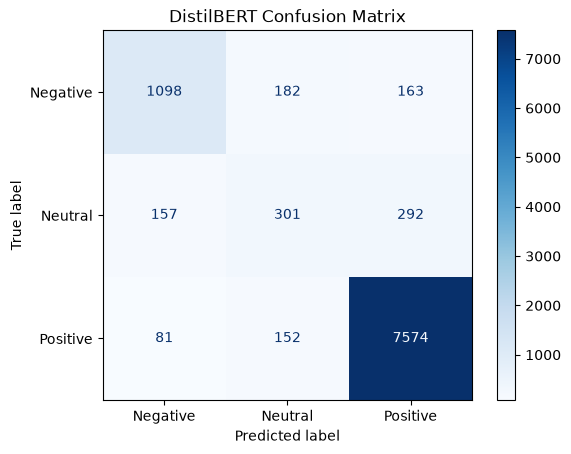

In [27]:
cm = confusion_matrix(
    y_true,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Neutral",
        "Positive"
    ]
)

disp.plot(cmap="Blues")

plt.title("DistilBERT Confusion Matrix")

plt.show()

In [28]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.8973


In [29]:
trainer.save_model("../models/distilbert_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [30]:
tokenizer.save_pretrained(
    "../models/distilbert_model"
)

('../models/distilbert_model\\tokenizer_config.json',
 '../models/distilbert_model\\tokenizer.json')

In [31]:
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification
)

tokenizer = DistilBertTokenizerFast.from_pretrained(
    "../models/distilbert_model"
)

model = DistilBertForSequenceClassification.from_pretrained(
    "../models/distilbert_model"
)

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [32]:
review = "This product is absolutely amazing."

inputs = tokenizer(
    review,
    return_tensors="pt",
    truncation=True,
    padding=True
)

outputs = model(**inputs)

prediction = torch.argmax(
    outputs.logits,
    dim=1
).item()

labels = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

print("Review :", review)
print("Prediction :", labels[prediction])

Review : This product is absolutely amazing.
Prediction : Positive


In [33]:
reviews = [

    "Amazing quality and worth every penny.",

    "Worst product I have ever bought.",

    "The product is okay, nothing special.",

    "Highly recommended to everyone.",

    "Not good at all."

]

labels = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

for review in reviews:

    inputs = tokenizer(
        review,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    outputs = model(**inputs)

    prediction = torch.argmax(
        outputs.logits,
        dim=1
    ).item()

    print(f"Review: {review}")
    print(f"Prediction: {labels[prediction]}")
    print("-" * 50)

Review: Amazing quality and worth every penny.
Prediction: Positive
--------------------------------------------------
Review: Worst product I have ever bought.
Prediction: Negative
--------------------------------------------------
Review: The product is okay, nothing special.
Prediction: Neutral
--------------------------------------------------
Review: Highly recommended to everyone.
Prediction: Positive
--------------------------------------------------
Review: Not good at all.
Prediction: Negative
--------------------------------------------------


In [34]:
comparison = {
    "Model": [
        "Logistic Regression",
        "Linear SVM",
        "DistilBERT"
    ],
    "Accuracy": [
        0.79,
        0.88,
        accuracy_score(y_true, y_pred)
    ]
}

comparison_df = pd.DataFrame(comparison)

print(comparison_df)

                 Model  Accuracy
0  Logistic Regression    0.7900
1           Linear SVM    0.8800
2           DistilBERT    0.8973
